# PROJECT 1  
by Szymon Waliczek
 - Impact of spatial quantization and transverse confinement on 2DEG electron transport in **InAs**.
 - **No magnetic field(B)**.

In [ ]:
import ipyparallel as ipp
cluster = ipp.Client(profile  = "kwant_parallel")
v = cluster[:]
lview = cluster.load_balanced_view()
len(v)

In [ ]:
%%px --local

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [ ]:
%%px --local

import kwant
import numpy as np

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

In [ ]:
%%px --local

# Physical constants
from scipy.constants import physical_constants
h_bar = physical_constants['Planck constant over 2 pi'][0]
m_el = physical_constants['electron mass'][0]
eV = physical_constants['electron volt'][0]
m_eff = 0.023 * m_el
a = 5e-9
# hopping in eV
t = (h_bar**2 / (2 * m_eff * a**2)) / eV
W, L = 20, 30
freedom_deg = 1;

In [ ]:
%%px --local

# System
def make_system(W, L, a, t, deg):
    lat = kwant.lattice.square(a, norbs=deg)

    sys = kwant.Builder()
    sys[(lat(i, j) for i in range(W) for j in range(L))] = 4 * t
    sys[lat.neighbors()] = -t
    
    return sys, lat
#-------------------------------------------------------------------------
# Lead
def make_lead(sys, lat, a, t, W):
    sym_lead = kwant.TranslationalSymmetry((0, -a))
    lead = kwant.Builder(sym_lead)
    lead[(lat(i, 0) for i in range(W))] = 4 * t
    lead[lat.neighbors()] = -t

    sys.attach_lead(lead)
    sys.attach_lead(lead.reversed())

    return lead

In [ ]:
def plot_system(sys):
    kwant.plot(sys, fig_size=(2, 3.5), show=False)
    plt.title("Lattice InAs (a = 5nm)") 
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.ticklabel_format(axis='both', style='sci', scilimits=(-9, -9), useMathText=True)
    plt.show()

In [ ]:
%%px --local

sys, lat = make_system(W, L, a, t, freedom_deg)
lead = make_lead(sys, lat, a, t, W)
fsys = sys.finalized()

In [ ]:
plot_system(fsys)

Energy relation with momentum in x_axis:

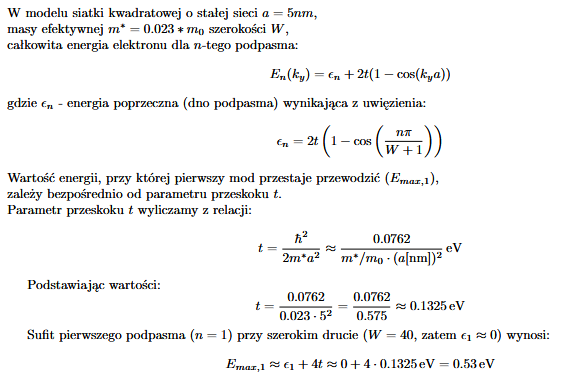

In [ ]:
# Relation of dispersion - bottom lead
kwant.plotter.bands(fsys.leads[0], show=False)
plt.title("$E(k_x)$ bottom lead")
plt.xlabel("$k_y [1/a]$")
plt.ylabel("[eV]")
plt.ylim(0, 0.02)
plt.xlim(-1,1)
plt.show()

In [ ]:
%%px --local

def compute_conductance(energy, sys):
    smatrix = kwant.smatrix(sys, energy)
    return smatrix.transmission(1, 0)

In [ ]:
def plot_conductance(sys, Eb, Ef, n):
    energies = np.linspace(Eb, Ef, n)
    conductance = lview.map_sync(lambda e: compute_conductance(e, sys), energies)
    plt.figure(figsize=(5, 3))
    plt.plot(energies, conductance, lw=2)
    plt.xlabel("E [eV]"); 
    plt.ylabel("G [$e^2/h$]"); 
    plt.grid(True)
    plt.show()

In [ ]:
plot_conductance(fsys, 0, 0.2, 100)

In [ ]:
def plot_wave_function(fsys, energies):
    plt.figure(figsize=(12, 4))
    for i in range(len(energies)):
        wf = kwant.wave_function(fsys, energy=energies[i])(0)
        if len(wf) > 0:
            kwant.plotter.map(fsys, sum(kwant.operator.Density(fsys)(p) for p in wf), 
                              ax=plt.subplot(1, 6, i + 1), show=False,)
            plt.title(f"E = {energies[i]} eV")
            plt.xlabel("x [nm]")
            if i == 0: plt.ylabel("y [nm]")
        else:
            print(f"Brak modów dla E = {energies[i]} eV.")
            
    plt.tight_layout()
    plt.show()

In [ ]:
energies = [0.01, 0.02, 0.05]
plot_wave_function(fsys, energies)

In [ ]:
def plot_current_density(fsys, energies):
    plt.figure(figsize=(12, 4))
    for i in range(len(energies)):
        E = energies[i]
        wf = kwant.wave_function(fsys, energy=E)(0)
        if len(wf) > 0:
            current = sum(kwant.operator.Current(fsys)(p) for p in wf)
            kwant.plotter.current(fsys, current, ax=plt.subplot(1, 6, i + 1), show=False)
            
            plt.title(f"Prąd E = {E} eV")
            plt.xlabel("x [nm]")
            if i == 0: plt.ylabel("y [nm]")
        else:
            print(f"Brak modów dla E = {E} eV.")
            
    plt.tight_layout()
    plt.show()

In [ ]:
plot_current_density(fsys, energies)